## <b>Z-SCORE<hr style="border:2.5px solid rgba(255, 0, 0, 1)"></hr>

<b>Tangente, Kurt Clarence J.</b><br>
T09-A<br>
1/22/2025

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [17]:
df = pd.DataFrame([1,2,2,3,3,3,4,4,5],
                  columns=['Dataset'])

df

,Dataset
0,1
1,2
2,2
3,3
4,3
5,3
6,4
7,4
8,5


In [18]:
df.describe().round(2)

,Dataset
count,9.00
mean,3.00
std,1.22
min,1.00
25%,2.00
50%,3.00
75%,4.00
max,5.00


In [19]:
df['Z-Score'] = stats.zscore(df['Dataset'],ddof=1)
df.round(2)

,Dataset,Z-Score
0,1,-1.63
1,2,-0.82
2,2,-0.82
3,3,0.00
4,3,0.00
5,3,0.00
6,4,0.82
7,4,0.82
8,5,1.63


In [20]:
df['Z-Score'].mean()

0.0

In [21]:
df = pd.read_csv(r"dataset\current-test.csv",
                 delimiter=',',
                 index_col=0)
df.head()

,Current
Sample,
1,12.0
2,15.0
3,8.3
4,9.7
5,12.0


In [22]:
df['Current'][2]

15.0

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 1 to 30
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Current  30 non-null     float64
dtypes: float64(1)
memory usage: 1.5 KB


In [24]:
df.describe()

,Current
count,30.000000
mean,11.806667
std,3.166629
min,3.300000
25%,10.250000
50%,12.000000
75%,13.775000
max,21.500000


In [25]:
df['Z-score'] = stats.zscore(df['Current'], ddof=1)
df

,Current,Z-score
Sample,,
1,12.0,0.061053
2,15.0,1.008433
3,8.3,-1.107382
4,9.7,-0.665271
5,12.0,0.061053
6,13.9,0.661060
7,14.1,0.724219
8,9.2,-0.823168
9,12.4,0.187371


In [26]:
df['Z-score'].describe().round(1)

count    30.0
mean      0.0
std       1.0
min      -2.7
25%      -0.5
50%       0.1
75%       0.6
max       3.1
Name: Z-score, dtype: float64

## <b>HISTOGRAM<hr style="border:2.5px solid rgba(255, 0, 0, 1)"></hr>

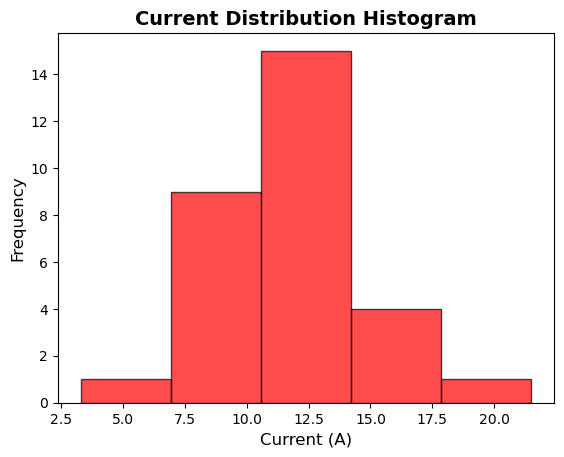

In [27]:
plt.hist(df['Current'], bins=5,
         alpha=0.7,
         color="#FF0000",
         edgecolor='black')

plt.title('Current Distribution Histogram',
          fontsize=14,
          fontfamily='Sans-Serif',
          fontweight='bold')
plt.xlabel('Current (A)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

## <b>NORMAL DISTRIBUTION<hr style="border:2.5px solid rgba(255, 0, 0, 1)"></hr>

C:\Users\evang\AppData\Local\Temp\ipykernel_9948\2954412949.py:10: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', color='black', linewidth=2)


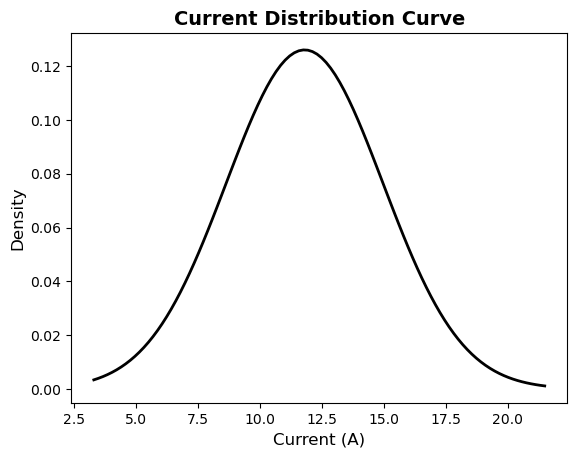

In [28]:
mean=df['Current'].mean()
std=df['Current'].std(ddof=1)

x_min = df['Current'].min()
x_max = df['Current'].max()

x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p, 'k', color='black', linewidth=2)
plt.title('Current Distribution Curve',
            fontsize=14,
            fontfamily='Sans-Serif',
            fontweight='bold')
plt.xlabel('Current (A)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.show()

C:\Users\evang\AppData\Local\Temp\ipykernel_9948\477998294.py:23: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', color='black', linewidth=2)


Text(0, 0.5, 'Density')

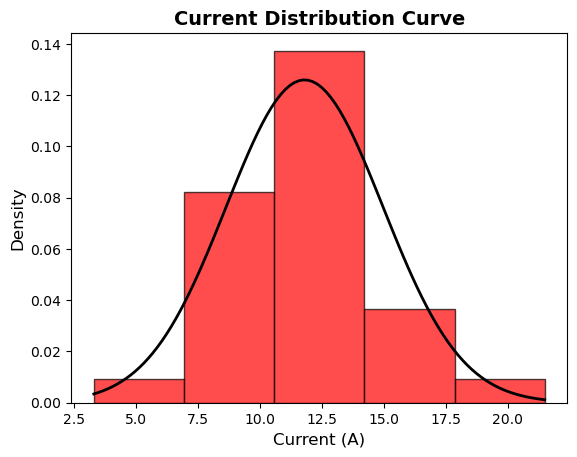

In [29]:
plt.hist(df['Current'], bins=5,
         density=True,
         alpha=0.7,
         color="#FF0000",
         edgecolor='black')

plt.title('Current Distribution Histogram',
          fontsize=14,
          fontfamily='Sans-Serif',
          fontweight='bold')
plt.xlabel('Current (A)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

mean=df['Current'].mean()
std=df['Current'].std(ddof=1)

x_min = df['Current'].min()
x_max = df['Current'].max()

x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)

plt.plot(x, p, 'k', color='black', linewidth=2)
plt.title('Current Distribution Curve',
            fontsize=14,
            fontfamily='Sans-Serif',
            fontweight='bold')
plt.xlabel('Current (A)', fontsize=12)
plt.ylabel('Density', fontsize=12)

## <b>STANDARD NORMAL DISTRIBUTION (0,1)<hr style="border:2.5px solid rgba(255, 0, 0, 1)"></hr>

C:\Users\evang\AppData\Local\Temp\ipykernel_9948\3537538533.py:7: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', color='black', linewidth=2)


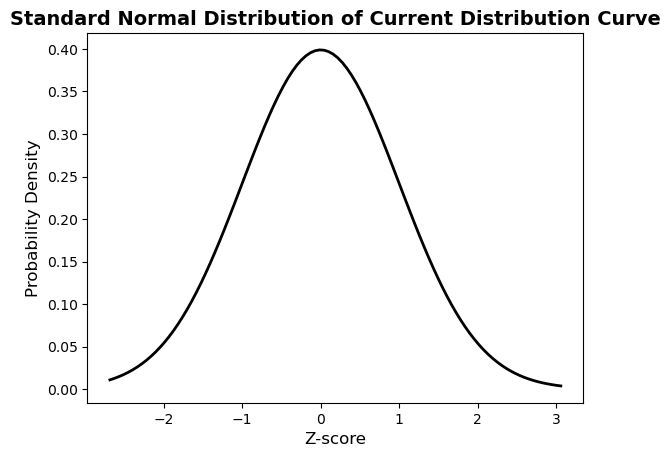

In [30]:
x_min = df['Z-score'].min()
x_max = df['Z-score'].max()

x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, df['Z-score'].mean(), df['Z-score'].std(ddof=1))

plt.plot(x, p, 'k', color='black', linewidth=2)
plt.figsize=(8,5)
plt.title('Standard Normal Distribution of Current Distribution Curve',
            fontsize=14,
            fontfamily='Sans-Serif',
            fontweight='bold')
plt.xlabel('Z-score', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.show()